In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
%cd /content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/DCX analysis

/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/DCX analysis


In [4]:
!pwd

/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/DCX analysis


### DCX 분석 프로세스
- 텍스트 데이터를 중심으로 고객의 문제점을 도출하고 새로운 기회영역을 찾아보는 분석 방법
- 3A 분석
    - Actor : 페르소나, 데이터를 통해서 고객을 정의 (텍스트 데이터에서 도출 된 인사이트에서 고객을 정의)
    - Action : 고객의 Needs에 따른 행동 정의 (pain point)
    - Artifact : Action을 수행하는 매개체

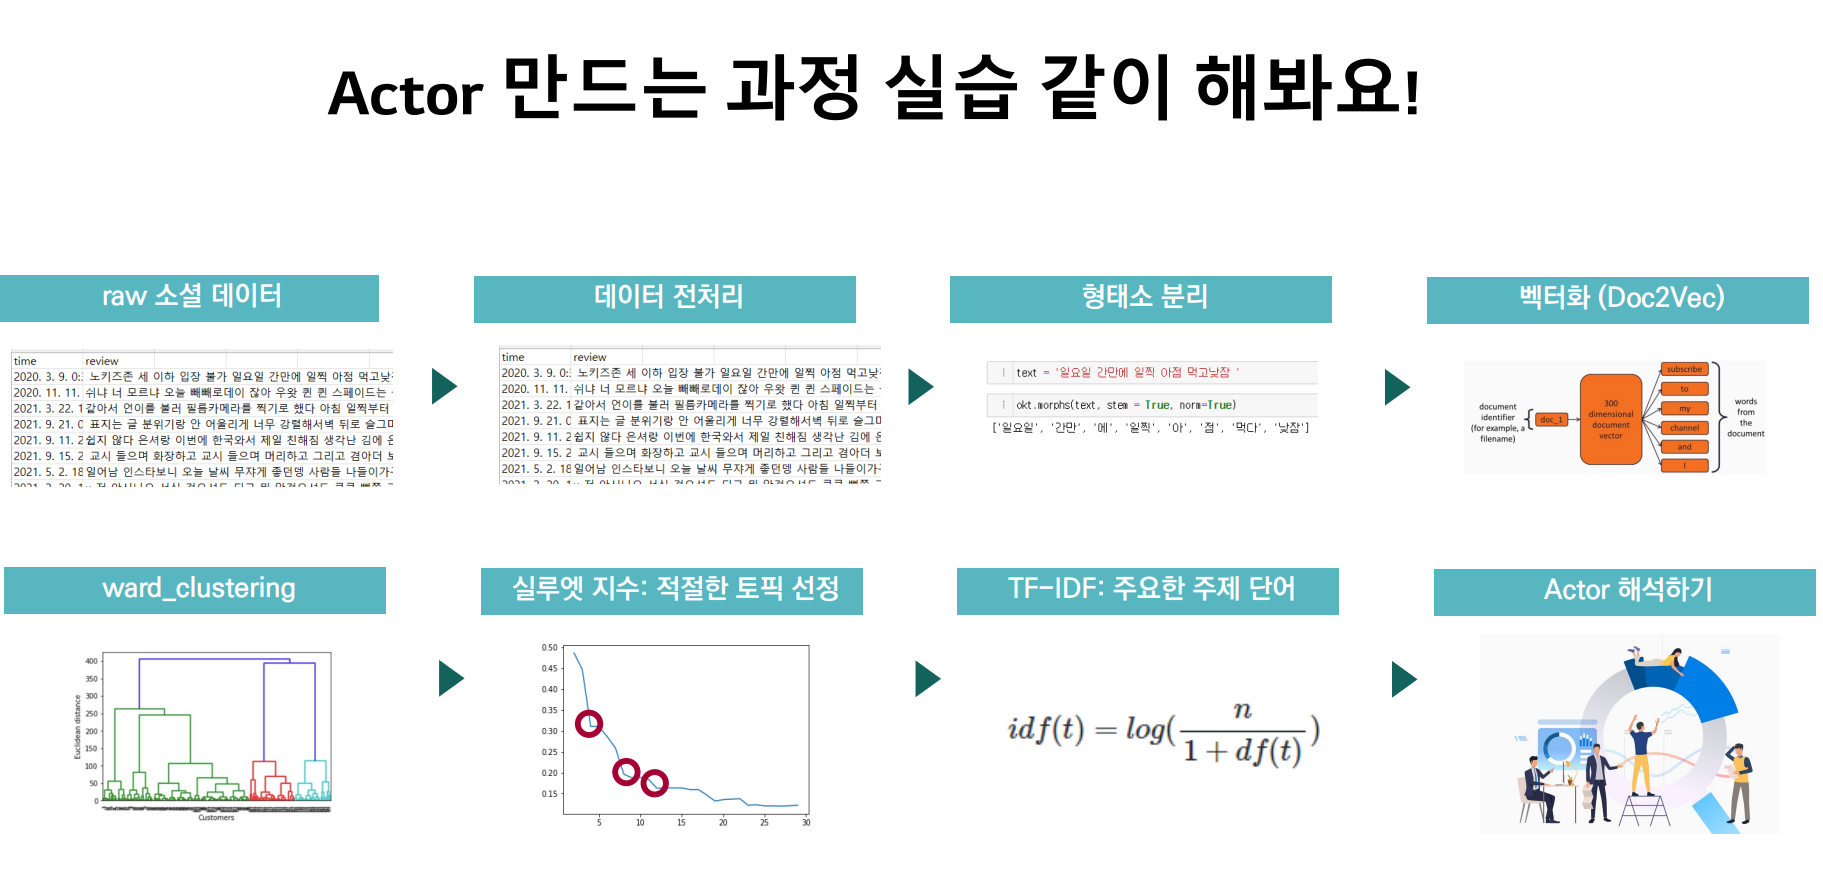

- raw 소셜 데이터
- 데이터 전처리 
- 형태소 분리
    - 필요한 형태소들 추출 : 주로 사용 (명사,동사,형용사) > 내가 주로 사용할 품사들 위주로
- 벡터화 (Doc2Vec)
- ward_clustering : 
- 실루엣 계수 : 적절한 토핑 선정 
- TF-IDF 주요한 주제 단어
- Actor 해석하기
    - 빈도기반의 해석 
    - 왜? embedding 기반의 해석은 사람이 보고 이해할 수 가 없음

### 1.데이터로딩

In [5]:
import pandas as pd

In [7]:
# 금융, 가계부, 대출 , 예금 등 다양한 사용자의 리뷰가 묶인 데이터로딩
df = pd.read_csv("./data/머니케어.csv")
df

,time,review
0,2023. 5. 30. 17:09,나의 가계부 지출 년 월 생활비 정산 만 원 가계부 인 가구 자취 생활비 식비 ...
1,2022. 10. 9. 22:41,신혼부부가계부 신혼부부 가계부화목 화목 신혼부부 가계부입당 화연휴 끝나고 오랜만에 ...
2,2022. 7. 2. 4:34,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...
3,2022. 7. 6. 5:19,카카오뱅크 청년전세자금대출 연장 년 금리변동 카카오뱅크 청년전세자금대출 서류금리...
4,2022. 8. 15. 18:08,우당탕탕 다신 안가고싶은 삼성병원 가지베이컨그라탕해먹기 미친 폭우랑 전쟁하기 ...
...,...,...
1014,2022. 10. 11. 11:05,스물셋 으로 보는 월의 첫주 밸런스프렌즈 토글 리더스 나한테 많은 영감을 주는 쯔지...
1015,2023. 2. 5. 22:20,직장인 갓생 탤이의 갓생 겨울방학 끝 동분서주 바쁜 탤이 공주놀이 넘 즐거워 모...
1016,2023. 4. 3. 14:11,청년전세임대주택 청약 일정 신청 서울특별시 순위로 청약 신청 위치한국토지주택공사...
1017,2022. 9. 23. 1:20,외쳐 갓생 하이루이번 글 사진 레전드 많음 최대 장수 나의 갓생 시작 먹던 햄...


In [8]:
df.head()

,time,review
0,2023. 5. 30. 17:09,나의 가계부 지출 년 월 생활비 정산 만 원 가계부 인 가구 자취 생활비 식비 ...
1,2022. 10. 9. 22:41,신혼부부가계부 신혼부부 가계부화목 화목 신혼부부 가계부입당 화연휴 끝나고 오랜만에 ...
2,2022. 7. 2. 4:34,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...
3,2022. 7. 6. 5:19,카카오뱅크 청년전세자금대출 연장 년 금리변동 카카오뱅크 청년전세자금대출 서류금리...
4,2022. 8. 15. 18:08,우당탕탕 다신 안가고싶은 삼성병원 가지베이컨그라탕해먹기 미친 폭우랑 전쟁하기 ...


In [ ]:
# 요약정보 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1019 entries, 0 to 1018
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   time    1019 non-null   object
 1   review  1019 non-null   object
dtypes: object(2)
memory usage: 16.1+ KB


In [11]:
# 데이터하나 확인
df.iloc[0,1]

'나의 가계부 지출  년 월 생활비 정산 만 원 가계부  인 가구 자취 생활비 식비 아끼기 고정지출 생활비 아끼기 무지출 직장인 짠테크 벌써 가계부를 작성한지 개월이 되었습니다월 생활비 원 월 생활비 원 월 생활비 원지난달 대비 원 오바가계부를 쓰고 있다는 게 의미가 없을 정도로비슷비슷한 개월 사실 이번 달 초부터저녁 약속 시험 원서 접수비 고양이 용품 등화끈하게 돈을 써버렸기 때문에남은 한 달을 쪼들린 사람 이츠미 그래도 이번 달은 당근 거래로무려 원이나 벌었답니다당근 거래 처음 해봐서떨려 했던 애송이는 중고거래 만렙이 되었습니다 이번 달은 갑작스럽게 생긴 약속이 있어서예상 비용은 벗어났지만그래도 힐링할 수 있어서 좋은 지출이었다고 봅니다 고양이 모래가 한 달에 만 원씩 들 줄은 몰랐습니다고양이 간식 밥 장난감도 아닌모래가 제일 비쌉니다 이번 달에 타투를 안 했다면 전월보다덜 썼던 거였는데 말이죠 하하후회는 전혀 없습니다이제부터는그저 가계부를 작성하는 것이 아닌분석을 해야겠습니다 외식 식비 공부 고양이 약 기타 약속을 줄이는 것밖에는 답이 없습니다물가가 후덜덜하네요월은 여름휴가 제외하고는공부에 열중할 터라생활비 만 원으로 목표해 보겠습니다파이팅 '

- 하나의 글이 긴게 좋음 

### 2. 데이터 전처리

#### 2.1 특수문자 제거
- 정규표현식(Regular Expression) 활용

In [12]:
import re

In [13]:
pattern = r'[^a-zA-Z0-9가-힣\s]'

```
re.sub(패턴, 치환할 문자열, 원본)
```

In [19]:
new_reviews = [re.sub(pattern,"",review) for review in df['review']] # 하나의 문장으로 만드는 과정

In [20]:
len(new_reviews)

1019

In [21]:
# 새로운 열로 추가 
df['review_clean'] = new_reviews
df

,time,review,review_clean
0,2023. 5. 30. 17:09,나의 가계부 지출 년 월 생활비 정산 만 원 가계부 인 가구 자취 생활비 식비 ...,나의 가계부 지출 년 월 생활비 정산 만 원 가계부 인 가구 자취 생활비 식비 ...
1,2022. 10. 9. 22:41,신혼부부가계부 신혼부부 가계부화목 화목 신혼부부 가계부입당 화연휴 끝나고 오랜만에 ...,신혼부부가계부 신혼부부 가계부화목 화목 신혼부부 가계부입당 화연휴 끝나고 오랜만에 ...
2,2022. 7. 2. 4:34,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...
3,2022. 7. 6. 5:19,카카오뱅크 청년전세자금대출 연장 년 금리변동 카카오뱅크 청년전세자금대출 서류금리...,카카오뱅크 청년전세자금대출 연장 년 금리변동 카카오뱅크 청년전세자금대출 서류금리...
4,2022. 8. 15. 18:08,우당탕탕 다신 안가고싶은 삼성병원 가지베이컨그라탕해먹기 미친 폭우랑 전쟁하기 ...,우당탕탕 다신 안가고싶은 삼성병원 가지베이컨그라탕해먹기 미친 폭우랑 전쟁하기 ...
...,...,...,...
1014,2022. 10. 11. 11:05,스물셋 으로 보는 월의 첫주 밸런스프렌즈 토글 리더스 나한테 많은 영감을 주는 쯔지...,스물셋 으로 보는 월의 첫주 밸런스프렌즈 토글 리더스 나한테 많은 영감을 주는 쯔지...
1015,2023. 2. 5. 22:20,직장인 갓생 탤이의 갓생 겨울방학 끝 동분서주 바쁜 탤이 공주놀이 넘 즐거워 모...,직장인 갓생 탤이의 갓생 겨울방학 끝 동분서주 바쁜 탤이 공주놀이 넘 즐거워 모...
1016,2023. 4. 3. 14:11,청년전세임대주택 청약 일정 신청 서울특별시 순위로 청약 신청 위치한국토지주택공사...,청년전세임대주택 청약 일정 신청 서울특별시 순위로 청약 신청 위치한국토지주택공사...
1017,2022. 9. 23. 1:20,외쳐 갓생 하이루이번 글 사진 레전드 많음 최대 장수 나의 갓생 시작 먹던 햄...,외쳐 갓생 하이루이번 글 사진 레전드 많음 최대 장수 나의 갓생 시작 먹던 햄...


- 다른 방법

In [ ]:
df['review'].apply(lambda x: re.sub(pattern, " ",x)) #이 코드는 각 데이터프레임에 적용하는 것

,review
0,나의 가계부 지출 년 월 생활비 정산 만 원 가계부 인 가구 자취 생활비 식비 ...
1,신혼부부가계부 신혼부부 가계부화목 화목 신혼부부 가계부입당 화연휴 끝나고 오랜만에 ...
2,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...
3,카카오뱅크 청년전세자금대출 연장 년 금리변동 카카오뱅크 청년전세자금대출 서류금리...
4,우당탕탕 다신 안가고싶은 삼성병원 가지베이컨그라탕해먹기 미친 폭우랑 전쟁하기 ...
...,...
1014,스물셋 으로 보는 월의 첫주 밸런스프렌즈 토글 리더스 나한테 많은 영감을 주는 쯔지...
1015,직장인 갓생 탤이의 갓생 겨울방학 끝 동분서주 바쁜 탤이 공주놀이 넘 즐거워 모...
1016,청년전세임대주택 청약 일정 신청 서울특별시 순위로 청약 신청 위치한국토지주택공사...
1017,외쳐 갓생 하이루이번 글 사진 레전드 많음 최대 장수 나의 갓생 시작 먹던 햄...


#### 2.2 의미없는 짧은 글 제거

In [22]:
# 리뷰길이가 10개 미만인 경우 삭제
drop_index = [] # 길이가 짧은 글의 인덱스를 저장할 리스트

for i, review in enumerate(df['review_clean']): #문장 전체반복처리
    if len(review)<10:
        drop_index.append(i)

In [23]:
drop_index

[]

- 길이가 10이하인 것은 없음. > drop을 통해 삭제
```
df.drop(drop_index, inplace = True)
```

In [26]:
# 리뷰길이가 10개 미만인 경우 삭제
# 내 코드
df['review_clean'].apply(lambda x: df.drop(x) if len(x)<10  )

SyntaxError: expected 'else' after 'if' expression (ipython-input-2780974323.py, line 3)

### 3.형태소 분리

#### 3.1 형태소 분리, 어간 추출, 정규화, 품사필터링, 불용어 제거

In [44]:
stopwords = pd.read_csv("./data/ko-stopwords.csv")

In [50]:
stopwords.head()

,stopwords
0,가
1,가까스로
2,가령
3,각
4,각각


In [56]:
stopwords_list = list(stopwords['stopwords'])

In [57]:
stopwords_list

['가',
 '가까스로',
 '가령',
 '각',
 '각각',
 '각자',
 '각종',
 '갖고말하자면',
 '같다',
 '같이',
 '개의치않고',
 '거니와',
 '거바',
 '거의',
 '것',
 '것과 같이',
 '것들',
 '게다가',
 '게우다',
 '겨우',
 '견지에서',
 '결과에 이르다',
 '결국',
 '결론을 낼 수 있다',
 '겸사겸사',
 '고려하면',
 '고로',
 '곧',
 '공동으로',
 '과',
 '과연',
 '관계가 있다',
 '관계없이',
 '관련이 있다',
 '관하여',
 '관한',
 '관해서는',
 '구',
 '구체적으로',
 '구토하다',
 '그',
 '그들',
 '그때',
 '그래',
 '그래도',
 '그래서',
 '그러나',
 '그러니',
 '그러니까',
 '그러면',
 '그러므로',
 '그러한즉',
 '그런 까닭에',
 '그런데',
 '그런즉',
 '그럼',
 '그럼에도 불구하고',
 '그렇게 함으로써',
 '그렇지',
 '그렇지 않다면',
 '그렇지 않으면',
 '그렇지만',
 '그렇지않으면',
 '그리고',
 '그리하여',
 '그만이다',
 '그에 따르는',
 '그위에',
 '그저',
 '그중에서',
 '그치지 않다',
 '근거로',
 '근거하여',
 '기대여',
 '기점으로',
 '기준으로',
 '기타',
 '까닭으로',
 '까악',
 '까지',
 '까지 미치다',
 '까지도',
 '꽈당',
 '끙끙',
 '끼익',
 '나',
 '나머지는',
 '남들',
 '남짓',
 '너',
 '너희',
 '너희들',
 '네',
 '넷',
 '년',
 '논하지 않다',
 '놀라다',
 '누가 알겠는가',
 '누구',
 '다른',
 '다른 방면으로',
 '다만',
 '다섯',
 '다소',
 '다수',
 '다시 말하자면',
 '다시말하면',
 '다음',
 '다음에',
 '다음으로',
 '단지',
 '답다',
 '당신',
 '당장',
 '대로 하다',
 '대하면',
 '대하여',
 '대해 말하자면',
 '대해서',
 '댕그',


In [46]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 61.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 32.2 MB/s eta 0:00:00


In [47]:
from konlpy.tag import Okt
okt = Okt()

In [52]:
sample_txt ="된다 짱이다 ㅋㅋㅋㅋㅋㅋㅋㅋㅋ"

In [58]:
for token,tag in okt.pos(sample_txt,stem=True,norm = True):
    if tag in ['Noun','Verb','Adjective']:
        print(token)

되다
짱


In [60]:
def pos_tagging(text):
    # 형태소 단위로 분리 + 품사정보 추출
    pos_words = okt.pos(text,stem=True,norm=True) # 어간 추출 및 정규화 속성 활성화
    
    # 중간결과 저장리스트 
    tagged_list = []
    for token, tag in pos_words:  # 한문장의 쪼개진 토큰을 반복처리
        if tag in ['Noun','Verb','Adjective']: # 명사,동사,형용사만 걸러내기
            if token not in stopwords_list: #불용어가 아닌 token만
                tagged_list.append(token)
    
    return tagged_list


In [61]:
pos_tagging(sample_txt)

['짱']

#### 3.2 함수 적용 후 새로운 열 추가

In [65]:
df['tagged_review'] = df['review_clean'].apply(pos_tagging)

In [64]:
df['review_clean'].apply(lambda x: pos_tagging(x))

,review_clean
0,"[가계부, 지출, 생활비, 정산, 만, 원, 가계부, 인, 가구, 자취, 생활비, ..."
1,"[신혼부부, 가계부, 신혼부부, 가계부, 화목, 화목, 신혼부부, 가계부, 입당, ..."
2,"[예금, 진실, 문득, 투자, 경제, 흐름, 알다, 예금, 안정, 이자, 바라보다,..."
3,"[카카오, 뱅크, 청년, 전세, 자금, 대출, 연장, 금리, 변동, 카카오, 뱅크,..."
4,"[탕, 다시다, 가다, 삼성, 병원, 가지, 베이컨, 그라탕, 해, 먹기, 미치다,..."
...,...
1014,"[스물, 보다, 주, 밸런스, 프렌즈, 토글, 리더, 스, 많다, 영감, 주다, 쯔..."
1015,"[직장인, 생, 탤이, 생, 겨울방학, 끝, 동분서주, 바쁘다, 탤, 공주, 넘다,..."
1016,"[청년, 전세, 임대주택, 청약, 일정, 신청, 서울특별시, 순위, 청약, 신청, ..."
1017,"[외치다, 생, 하이루, 글, 사진, 레전드, 많다, 최대, 장수, 생, 시작, 먹..."


- 헷갈리는 지점 : lambda함수를 언제 써야하는지? 
    - 함수 적용 이후 "전처리 추가" / "조건문 추가" 해야할 경우 lambda 함수를 적용한다. 즉 사용자 정의함수 이후에 뭔가 다른 걸 더 추가해야할때 lambda 함수를 이용해서 적용한다

In [66]:
df

,time,review,review_clean,tagged_review
0,2023. 5. 30. 17:09,나의 가계부 지출 년 월 생활비 정산 만 원 가계부 인 가구 자취 생활비 식비 ...,나의 가계부 지출 년 월 생활비 정산 만 원 가계부 인 가구 자취 생활비 식비 ...,"[가계부, 지출, 생활비, 정산, 만, 원, 가계부, 인, 가구, 자취, 생활비, ..."
1,2022. 10. 9. 22:41,신혼부부가계부 신혼부부 가계부화목 화목 신혼부부 가계부입당 화연휴 끝나고 오랜만에 ...,신혼부부가계부 신혼부부 가계부화목 화목 신혼부부 가계부입당 화연휴 끝나고 오랜만에 ...,"[신혼부부, 가계부, 신혼부부, 가계부, 화목, 화목, 신혼부부, 가계부, 입당, ..."
2,2022. 7. 2. 4:34,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...,"[예금, 진실, 문득, 투자, 경제, 흐름, 알다, 예금, 안정, 이자, 바라보다,..."
3,2022. 7. 6. 5:19,카카오뱅크 청년전세자금대출 연장 년 금리변동 카카오뱅크 청년전세자금대출 서류금리...,카카오뱅크 청년전세자금대출 연장 년 금리변동 카카오뱅크 청년전세자금대출 서류금리...,"[카카오, 뱅크, 청년, 전세, 자금, 대출, 연장, 금리, 변동, 카카오, 뱅크,..."
4,2022. 8. 15. 18:08,우당탕탕 다신 안가고싶은 삼성병원 가지베이컨그라탕해먹기 미친 폭우랑 전쟁하기 ...,우당탕탕 다신 안가고싶은 삼성병원 가지베이컨그라탕해먹기 미친 폭우랑 전쟁하기 ...,"[탕, 다시다, 가다, 삼성, 병원, 가지, 베이컨, 그라탕, 해, 먹기, 미치다,..."
...,...,...,...,...
1014,2022. 10. 11. 11:05,스물셋 으로 보는 월의 첫주 밸런스프렌즈 토글 리더스 나한테 많은 영감을 주는 쯔지...,스물셋 으로 보는 월의 첫주 밸런스프렌즈 토글 리더스 나한테 많은 영감을 주는 쯔지...,"[스물, 보다, 주, 밸런스, 프렌즈, 토글, 리더, 스, 많다, 영감, 주다, 쯔..."
1015,2023. 2. 5. 22:20,직장인 갓생 탤이의 갓생 겨울방학 끝 동분서주 바쁜 탤이 공주놀이 넘 즐거워 모...,직장인 갓생 탤이의 갓생 겨울방학 끝 동분서주 바쁜 탤이 공주놀이 넘 즐거워 모...,"[직장인, 생, 탤이, 생, 겨울방학, 끝, 동분서주, 바쁘다, 탤, 공주, 넘다,..."
1016,2023. 4. 3. 14:11,청년전세임대주택 청약 일정 신청 서울특별시 순위로 청약 신청 위치한국토지주택공사...,청년전세임대주택 청약 일정 신청 서울특별시 순위로 청약 신청 위치한국토지주택공사...,"[청년, 전세, 임대주택, 청약, 일정, 신청, 서울특별시, 순위, 청약, 신청, ..."
1017,2022. 9. 23. 1:20,외쳐 갓생 하이루이번 글 사진 레전드 많음 최대 장수 나의 갓생 시작 먹던 햄...,외쳐 갓생 하이루이번 글 사진 레전드 많음 최대 장수 나의 갓생 시작 먹던 햄...,"[외치다, 생, 하이루, 글, 사진, 레전드, 많다, 최대, 장수, 생, 시작, 먹..."


#### 3.3 pickle 파일로 중간결과 저장하기

In [67]:
df.to_pickle('./data/tagged_review.pkl')

3.4 pickle 파일 로딩하기

In [ ]:
df = pd.read_pickle('./data/tagged_review.pkl')

### 4. 벡터화(수치화)
- 컴퓨터는 사람의 말을 이해할 수 없음 -> 숫자로 변경해주어야함
#### Doc2Vec
- word2vec는 단어 하나를 하나의 vector로 변환
    - CBOW,SKipgram
- doc2vec은 문서 하나를 하나의 vector로 변환
    - PV-DM model,Pv-DBoW


- DM : Distributed Memory
    - 벡터와 앞의 단어들을 사용해서 다음에 나오는 단어를 유추
    - 윈도우 크기 내의 단어들을 Input으로 사용
    - 벡터가 학습 시 문서의 주제를 잡아주는 메모리 역할 수행
    - 일반적으로 DBoW보다 성능이 우수
- DBoW : Distributed Bag of Word
    - ID를 가지고 단어를 랜덤하게 예측하는 방식

In [ ]:
!pip install new_value_analysis

In [ ]:
from new_value_analysis.act import train_doc2vec_module

4.1 문서 ID 리스트

In [ ]:
model, vector_list, tagged_corpus_list = train_doc2vec_module(
    df, # 학습에 사용할 dataframe
    token_col = 'tagged_review' # 벡터화를 수행할 컬럼명 지정
    vector_size = 100, # 학습할 벡터의 차원(크기) 수
    alpha = 0.025 #학습률
    min_alpha = 0.001, # 학습 진행 중에 점차 감소시킬 최소 학습률
    window = 8, # 주변 단어(window) 범위 설정(중심단어 기준 앞뒤 8개씩)
    epohcs = 5, # 학습횟수설정
    tag_prefix = 'document' # 문서 ID 태깅 명칭
)

In [ ]:
# 모델 확인
model

In [ ]:
# 첫번째 문서 vector 확인
vector_list[0]
# 첫번째 문서 ID 확인
tagged_corpus_list[0]
# 문서 벡터 크기 확인
len(vector_list[0])


4.2 데이터프레임에 새로운 열로 벡터결과 추가

In [ ]:
df['doc2vec_vector'] = vector_list

### 5. 클러스터링(군집화) 분석을 통한 Actor 선정

#### 5.1 ward 기준으로 덴드로그램 그려보기

``plot dendrogram``


    - Doc2Vec으로 문서를 벡터화한 뒤, 그 벡터들을 토대로 계층적 군집을 수행 -> 덴드로그램으로 문서들이 어떤 구조로 묶이는지 한눈에 확인
    - 이후 실루엣 지수 등 다른 지표와 함께 종합적으로 가장 적절한 군집 수를 결정
    - `계층적 군집` : 모든 데이터간의 거리를 계산한 뒤, 가장 가까운 데이터부터 차례대로 묶어 나가며 점점 더 큰 군집을 만들어가는 방법, 최종적으로는 하나의 군집으로 합쳐진다.

In [ ]:
from new_value_analysis.actor_finder import plot_dendrogram

In [ ]:
linked = plot_dendrogram(
    df, # 사용할 dataframe
    vector_col = 'vector', # 군집을 위한 계산 대상이 되는 컬럼 설정
    method = 'ward', # 군집 방법 설정
    figsize = (10,10), # 그래프 크기 설정
    orientation = 'top' # 그래프 방향 설정(위에서 아래로)
    color_threshold = 16 # 색상 임계치 설정
)



5.2 실루엣 계수 분석 (엘보우 기법)
- `실루엣 계수` : 군집화 모델의 성능을 평가하는 지표
    - 개별 데이터가 포함된 군집 내부는 얼마나 촘촘한지 (응집도), 다른 군집과는 얼마나 떨어져 있는지 (분리도)를 -1 ~ 1 사이의 값으로 수치화한 점수
- 덴드로그램만으로는 '잘 나누었는가' 에 대한 적절한 판단은 어려움
- 실루엣 계수를 활용하여 군집 개수 평가가 가능!
``agglomerative_silhouette_module()``

- 데이터 프레임을 입력받아, 원하는 군집개수, 군집 방식을 설정하면 평균 실루엣 지수를 자동으로 계산하고 시각화해주는 함수

In [ ]:
from new_value_analysis.actor_finder import agglomerative_silhouette_module

In [ ]:
agglomerative_silhouette_module(
    df, # 사용할 dataframe
    vector_col = 'doc2vec_vector', # 군집을 위한 계산 대상이 되는 컬럼 설정
    linkage = 'ward', # 군집 방법 설정
    figsize = (10,10), # 그래프 크기 설정
    n_clusters_range = (2,10) # 클러스터 개수별 실루엣 지수확인
)


- 군집의 응집도와 분리도가 좋을수록 1에 가까운 결과값이 나온다
- 특히 실루엣계수의 변화폭이 큰 구간이 정보의 변화가 커서 해석하기 좋은 군집 수일 가능성이 높다 (엘보우 기법)
- 군집의 의미가 좋다라고 해석하는 건 별도로 텍스트분석을 수행해야한다.
- 다이어그램과 실루엣계수 그래프를 복합적으로 보면서 시작 군집수를 설정

``visaulize_silhouette``

- 실루엣 다이어그램 분석
- 평균 실루엣 지수 분석에서 추가적으로 실루엣 다이어그램으로도 분석가능


In [ ]:
from new_value_analysis.actor_finder import visualize_silhouette

In [ ]:
visualize_silhouette(range(2,10),list(df['vector']))

5.3 선정한 개수로 군집 실시

In [ ]:
from sklearn.cluster import AgglomerativeClustering

In [ ]:
# 군집도구 생성
cluster = AgglomerativeClustering(
    n_clusters = 3, # 군집 개수 설정
    affinity = 'euclidean', # 거리 측정 방법 설정
    linkage = 'ward' # 군집 방법 설정
)

In [ ]:
cluster_labels = cluster.fit_predict(df['vector']) # 학습 및 예측을 한번에 수행 

In [ ]:
cluster_labels

In [ ]:
df['cluster'] = cluster_labels

In [ ]:
#파일로 저장
df.to_pickle('./data/cluster_df.pkl')